In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load data
train_data = pd.read_csv('../titanic/train.csv')
test_data = pd.read_csv('../titanic/test.csv')


In [2]:
# 2. Data preprocessing
# Fill missing values
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].median())
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])
train_data = train_data.drop(columns=['Cabin'])

test_data['Age'] = test_data['Age'].fillna(test_data['Age'].median())
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())
test_data = test_data.drop(columns=['Cabin'])

# Convert categorical features to numeric values
label_encoder = LabelEncoder()
train_data['Sex'] = label_encoder.fit_transform(train_data['Sex'])
train_data['Embarked'] = label_encoder.fit_transform(train_data['Embarked'])

test_data['Sex'] = label_encoder.fit_transform(test_data['Sex'])
test_data['Embarked'] = label_encoder.fit_transform(test_data['Embarked'])


In [3]:
# 3. Prepare features and target variable
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = train_data[features]  # Training set features
y = train_data['Survived']  # Target variable

X_test = test_data[features]  # Test set features

# 4. Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [4]:
# 6. Build and train the SVM model
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# 7. Evaluate the model on the validation set
y_val_pred = svm_model.predict(X_val_scaled)
accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation model accuracy: {accuracy:.2f}")
print("Classification report:\n", classification_report(y_val, y_val_pred))


Validation model accuracy: 0.78
Classification report:
               precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



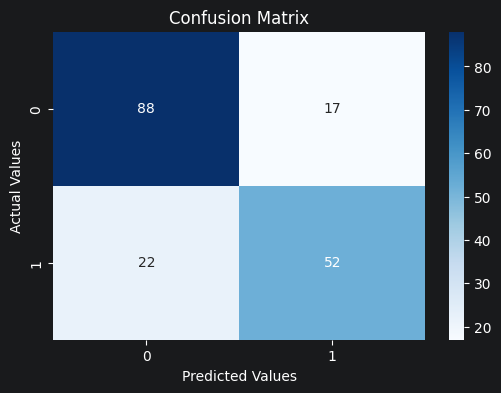

In [5]:
# 8. Confusion Matrix
plt.figure(figsize=(6, 4))
conf_matrix = confusion_matrix(y_val, y_val_pred)
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()


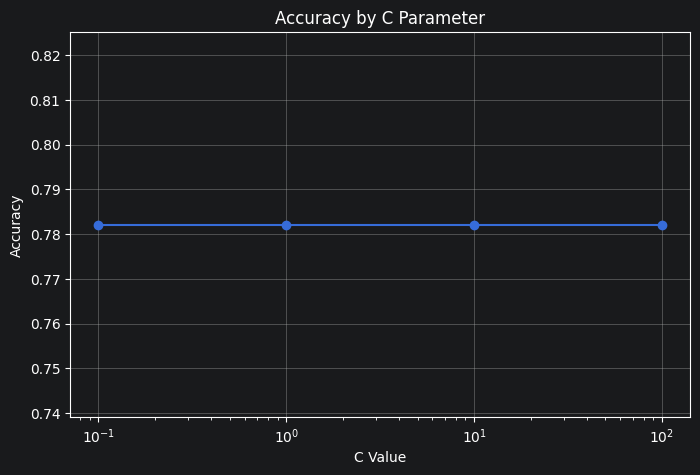

In [6]:
# 9. Visualize accuracy by C parameter
C_values = [0.1, 1.0, 10.0, 100.0]
accuracies = []

for C in C_values:
    svm_model = SVC(kernel='linear', C=C, random_state=42)
    svm_model.fit(X_train_scaled, y_train)
    y_val_pred = svm_model.predict(X_val_scaled)
    accuracies.append(accuracy_score(y_val, y_val_pred))

plt.figure(figsize=(8, 5))
plt.plot(C_values, accuracies, marker='o')
plt.title("Accuracy by C Parameter")
plt.xlabel("C Value")
plt.ylabel("Accuracy")
plt.xscale('log')  # Logarithmic scale for the C axis
plt.grid(True)
plt.show()


In [7]:
# 10. Predictions on the test set
y_pred = svm_model.predict(X_test_scaled)

# 11. Save predictions to submission.csv
submission_data = pd.read_csv("../titanic/gender_submission.csv")[['PassengerId']]
submission_data['Survived'] = y_pred
submission_data.to_csv('submission.csv', index=False)

print("Predictions have been saved to submission.csv")

real_y = submission_data['Survived']
pred_vs_real = pd.DataFrame({
    'Predicted': y_pred[:10],
    'Real': real_y[:10]
})
print("First 10 predictions and actual values:")
print(pred_vs_real)


Predictions have been saved to submission.csv
First 10 predictions and actual values:
   Predicted  Real
0          0     0
1          1     1
2          0     0
3          0     0
4          1     1
5          0     0
6          1     1
7          0     0
8          1     1
9          0     0
